# 运动想象解码 benchmark:BCICIV-2a vs Lee2019

这是我毕设里 benchmark 的结果展示部分。在两个公开的运动想象(MI)数据集 BCICIV-2a(9 人、4 类)和 Lee2019(54 人、2 类)上,对比四种解码方法(CSP+LDA、MDM、TS-LR、EEGNet)和一个自研的无监督域适应方法(RPA)。两个评估协议:**同会话 5 折 CV**(通道从全 montage 缩到 4 个)和**跨会话**(训练、测试用不同 session),两个数据集都跑;并在此基础上分析从同会话到跨会话的退化、用 RPA 恢复跨会话损失、以及跨数据集对比。两个数据集随机水平不同(25% vs 50%),跨数据集比较用 κ 归一化,并报告效应量 dz 与 Holm 校正后的显著性。

> 所有计算都在 `.py` 脚本里离线跑,这个 notebook 只负责读结果和画图,不重新计算。

## 数据来源与复现

下面的数字全部来自 `results/` 里的 CSV,由实验脚本生成。每个数据集都是「跨会话」+「同会话(含通道缩减)」两个文件,结构对称;同会话基线就是通道缩减表里的全通道点(2a K=22 / Lee2019 K=62):

| CSV | 生成脚本 | 数据集 / 内容 |
|---|---|---|
| `exp_baseline_v2.csv` | `experiments/run_cross_session.py` | 2a(9 人):跨会话(notebook 取其 cross-session 行) |
| `exp_channel_reduction.csv` | `experiments/run_channel_reduction.py` | 2a(9 人):同会话 5 折 CV,通道从 22 缩到 4(全通道 K=22 即同会话基线) |
| `exp_lee2019_cross_session.csv` | `experiments/run_lee2019_overnight.py` | Lee2019(54 人):跨会话 |
| `exp_lee2019_channel_reduction.csv` | `experiments/run_lee2019_overnight.py` | Lee2019(54 人):同会话 5 折 CV,通道从 62 缩到 4(全通道 K=62 即同会话基线) |

复现 Lee2019(n=54,在 Apple MPS 上约 6 小时):

```bash
python -m experiments.run_lee2019_overnight --methods all
```

## 数据集概览

| | BCICIV-2a | Lee2019_MI |
|---|---|---|
| 类别 | 4 类(左/右手、脚、舌) | 2 类(左/右手) |
| 随机水平 | 25% | 50% |
| 被试 | 9 | 54 |
| 每会话 trial | **288**(72/类) | **100**(50/类) |
| 通道 | 22 | 62 |

Note:(1) 类别数不同,**两个数据集的绝对准确率不能直接比**,跨数据集对比用归一化的 κ;(2) Lee2019 每会话只有 100 个 trial,比 2a 的 288 少了快 3 倍,这点在解释 EEGNet 时很关键。

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare

RESULTS = Path("../results")
BASE = ["CSP+LDA", "MDM", "TS-LR", "EEGNet"]
COLORS = {"CSP+LDA": "#4C72B0", "MDM": "#55A868", "TS-LR": "#C44E52", "EEGNet": "#8172B3"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

lee_cross = pd.read_csv(RESULTS / "exp_lee2019_cross_session.csv")
lee_cr    = pd.read_csv(RESULTS / "exp_lee2019_channel_reduction.csv")
a_cross   = pd.read_csv(RESULTS / "exp_baseline_v2.csv").query("protocol == 'cross-session'")
a_cr      = pd.read_csv(RESULTS / "exp_channel_reduction.csv")

kappa = lambda acc, chance: (acc - chance) / (1 - chance)
def dz(a, b):
    d = (a - b).dropna(); return d.mean() / d.std()
print("loaded:", lee_cross.shape, lee_cr.shape, a_cross.shape, a_cr.shape)

loaded: (270, 4) (1080, 4) (45, 4) (180, 4)


## 通道缩减:全 montage 砍到 4 通道,看各方法掉多少(同会话 5 折 CV)

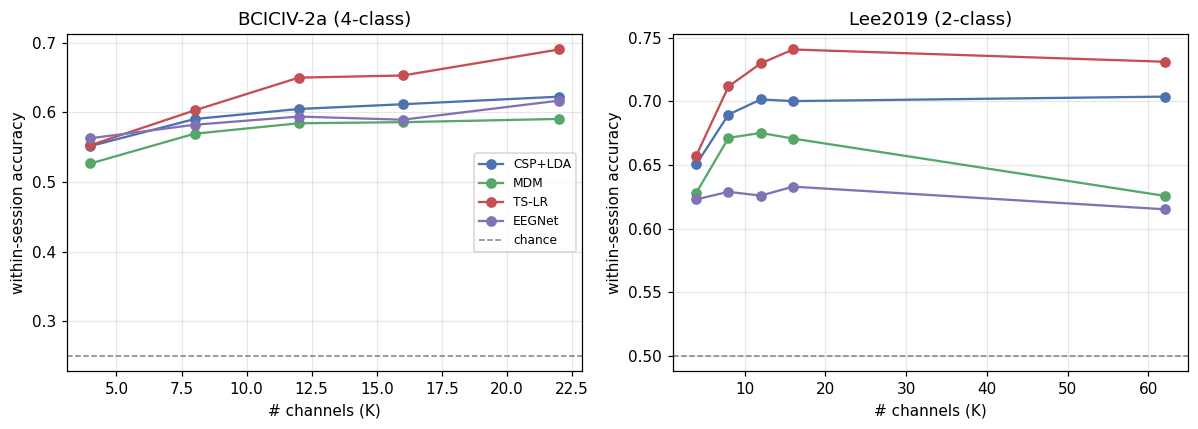

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, cr, chance) in zip(axes, [("BCICIV-2a (4-class)", a_cr, 0.25),
                                         ("Lee2019 (2-class)", lee_cr, 0.50)]):
    ks = sorted(cr.n_channels.unique())
    for m in BASE:
        means = [cr[(cr.method == m) & (cr.n_channels == k)].score.mean() for k in ks]
        ax.plot(ks, means, "o-", color=COLORS[m], label=m)
    ax.axhline(chance, ls="--", c="gray", lw=1, label="chance")
    ax.set_title(name); ax.set_xlabel("# channels (K)"); ax.set_ylabel("within-session accuracy")
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

通道多的时候 **TS-LR 明显领先**(CSP+LDA 在 Lee2019 上也接近);砍到 4 通道时各方法差距收窄。规律是**依赖全脑协方差结构的方法(TS-LR、CSP)降幅最大**:2a 上 TS-LR 的 dz 达 +2.84,通道减少后这一优势消失。

EEGNet 在 Lee2019 上基本持平(dz≈0)。MDM 在 Lee2019 上是**先升后降**:从 62 通道减到 12 通道附近时准确率反而上升(0.626 到 0.675),再减到 4 通道回落到 0.628,两端接近所以整体 dz≈0,但中间存在一个峰值;可能是通道过多时协方差估计不稳,适当降维改善了黎曼均值的估计。2a(9 人、22 通道)上 MDM/EEGNet 也随通道减少而下降(MDM dz+1.24、EEGNet dz+0.94),只是降幅小于领先方法。

## 跨会话:训练一个 session、测试另一个(不同天),真实 BCI 最难的场景

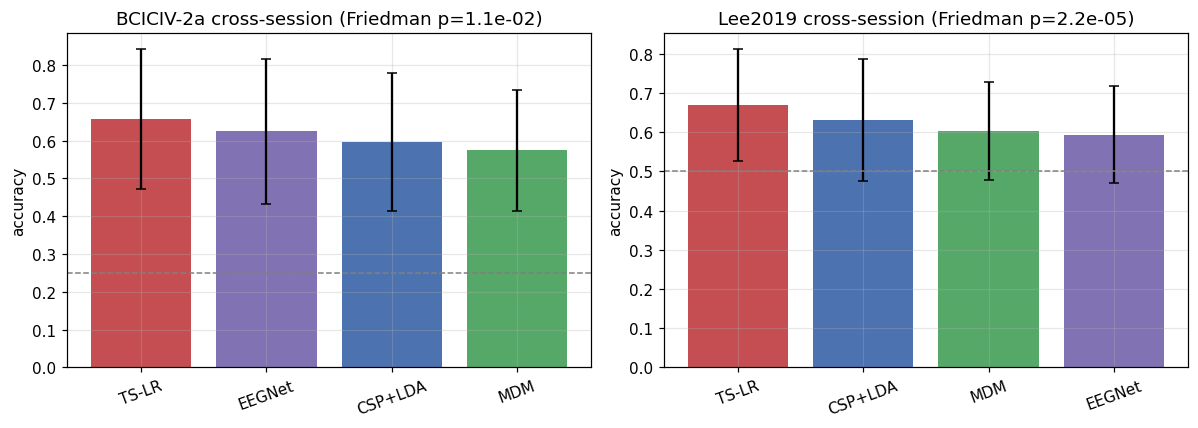

Lee2019 cross-session, TS-LR vs each (Wilcoxon p, dz):
  TS-LR vs CSP+LDA : p=3.7e-03  dz=+0.36
  TS-LR vs MDM     : p=8.1e-06  dz=+0.68
  TS-LR vs EEGNet  : p=4.9e-05  dz=+0.65


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, df, chance) in zip(axes, [("BCICIV-2a", a_cross, 0.25),
                                         ("Lee2019", lee_cross, 0.50)]):
    P = df[df.method.isin(BASE)].pivot_table(index="subject", columns="method", values="score")
    order = P[BASE].mean().sort_values(ascending=False)
    ax.bar(range(len(order)), order.values, yerr=[P[m].std() for m in order.index],
           color=[COLORS[m] for m in order.index], capsize=3)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order.index, rotation=20)
    ax.axhline(chance, ls="--", c="gray", lw=1)
    chi, p = friedmanchisquare(*[P[m] for m in BASE])
    ax.set_title(f"{name} cross-session (Friedman p={p:.1e})"); ax.set_ylabel("accuracy")
fig.tight_layout(); plt.show()

P = lee_cross[lee_cross.method.isin(BASE)].pivot_table(index="subject", columns="method", values="score")
print("Lee2019 cross-session, TS-LR vs each (Wilcoxon p, dz):")
for m in ["CSP+LDA", "MDM", "EEGNet"]:
    print(f"  TS-LR vs {m:8s}: p={wilcoxon(P['TS-LR'], P[m])[1]:.1e}  dz={dz(P['TS-LR'], P[m]):+.2f}")

**TS-LR 在两个数据集上都是第一。** 最大的变化是 EEGNet:在 2a(4 类)上它还排第二,到了 Lee2019(2 类)直接垫底。在 Lee2019 上 TS-LR 显著优于其余三个(Holm 校正后仍然成立)。

## 退化:从同会话到跨会话,各方法掉多少

BCICIV-2a degradation (within-cross), paired Wilcoxon:
  CSP+LDA  Δ=+0.027  p=5.0e-01
  MDM      Δ=+0.017  p=3.6e-01
  TS-LR    Δ=+0.033  p=5.5e-02
  EEGNet   Δ=-0.007  p=1.0e+00
Lee2019 degradation (within-cross), paired Wilcoxon:
  CSP+LDA  Δ=+0.072  p=2.8e-05
  MDM      Δ=+0.023  p=2.2e-02
  TS-LR    Δ=+0.062  p=2.7e-05
  EEGNet   Δ=+0.022  p=1.0e-01


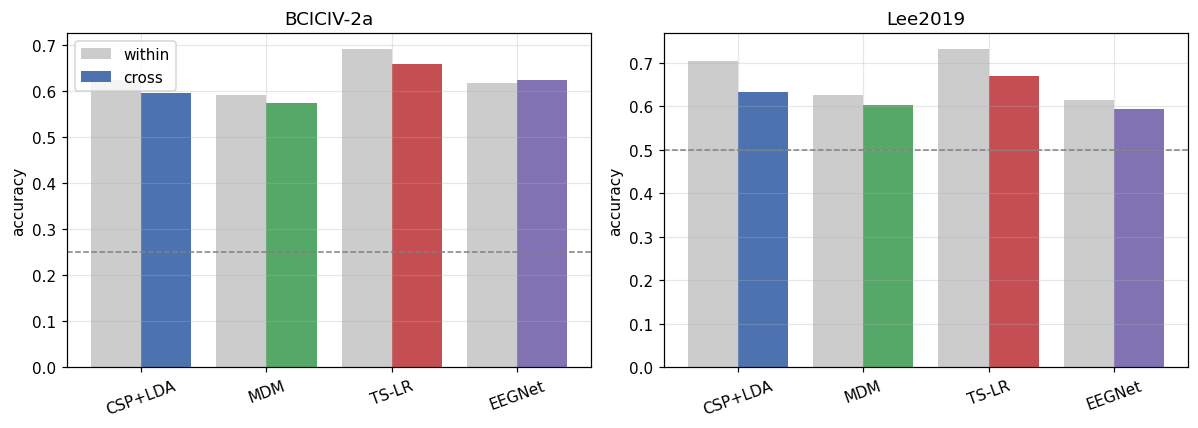

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, cr, full, crossdf, chance) in zip(axes, [
        ("BCICIV-2a", a_cr, 22, a_cross, 0.25),
        ("Lee2019", lee_cr, 62, lee_cross, 0.50)]):
    win = cr[cr.n_channels == full].pivot_table(index="subject", columns="method", values="score")
    crs = crossdf[crossdf.method.isin(BASE)].pivot_table(index="subject", columns="method", values="score")
    x = np.arange(len(BASE))
    ax.bar(x - 0.2, [win[m].mean() for m in BASE], 0.4, color="#cccccc", label="within")
    ax.bar(x + 0.2, [crs[m].mean() for m in BASE], 0.4, color=[COLORS[m] for m in BASE], label="cross")
    ax.set_xticks(x); ax.set_xticklabels(BASE, rotation=20)
    ax.axhline(chance, ls="--", c="gray", lw=1); ax.set_title(name); ax.set_ylabel("accuracy")
    print(f"{name} degradation (within-cross), paired Wilcoxon:")
    for m in BASE:
        w, c = win[m].align(crs[m], join="inner")
        print(f"  {m:8s} Δ={(w-c).mean():+.3f}  p={wilcoxon(w, c)[1]:.1e}")
axes[0].legend()
fig.tight_layout(); plt.show()

在 9 人的 2a 上,**所有方法的退化都不显著**(p>0.05):不是没有退化,而是样本量不足以检出。到 54 人,CSP/TS-LR 的退化都显著(p<3e-5)。EEGNet 退化最小,但这是 **floor effect**:它本身就低(同会话也只有 ~0.61),几乎没有可退化的空间。

至于 EEGNet 为什么整体偏弱:**Lee2019 每会话只有 100 个 trial(50/类),2a 有 288 个(72/类),少了快 3 倍**。EEGNet 是数据饥饿的 CNN,在这么小的标定数据上训练不充分;CSP/黎曼这类方法数据效率更高,在小数据上更稳定。

## RPA 域适应(自研):预测时把目标 session 协方差按其黎曼均值重新中心化,无监督、不需目标标签,直接针对上面的跨会话退化

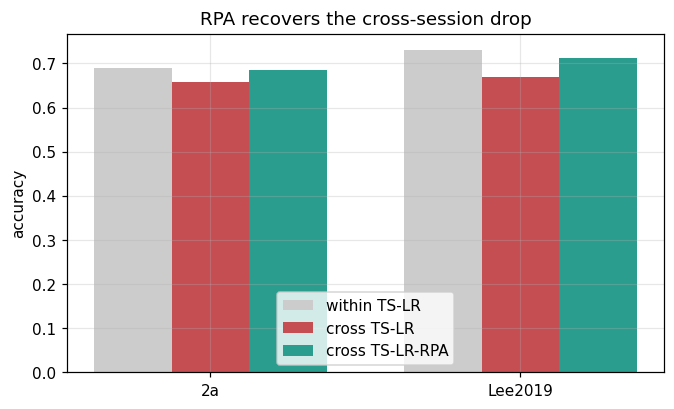

2a      : retention 95.2% -> 99.3%  (RPA p=5.5e-02, dz=+0.75)
Lee2019 : retention 91.5% -> 97.4%  (RPA p=2.5e-05, dz=+0.62)


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = []
for name, cr, full, crossdf in [("2a", a_cr, 22, a_cross), ("Lee2019", lee_cr, 62, lee_cross)]:
    win = cr[cr.n_channels == full].pivot_table(index="subject", columns="method", values="score")["TS-LR"]
    P = crossdf.pivot_table(index="subject", columns="method", values="score")
    groups.append((name, win.mean(), P["TS-LR"].mean(), P["TS-LR-RPA"].mean(),
                   wilcoxon(P["TS-LR-RPA"], P["TS-LR"])[1], dz(P["TS-LR-RPA"], P["TS-LR"])))
x = np.arange(len(groups)); w = 0.25
ax.bar(x - w, [g[1] for g in groups], w, color="#cccccc", label="within TS-LR")
ax.bar(x,     [g[2] for g in groups], w, color="#C44E52", label="cross TS-LR")
ax.bar(x + w, [g[3] for g in groups], w, color="#2A9D8F", label="cross TS-LR-RPA")
ax.set_xticks(x); ax.set_xticklabels([g[0] for g in groups]); ax.set_ylabel("accuracy")
ax.set_title("RPA recovers the cross-session drop"); ax.legend()
plt.show()
for name, win, ts, rpa, p, d in groups:
    print(f"{name:8s}: retention {ts/win*100:.1f}% -> {rpa/win*100:.1f}%  (RPA p={p:.1e}, dz={d:+.2f})")

RPA 把 TS-LR 的跨会话保持率从 91.5% 提高到 97.4%,恢复了约 70% 的退化。效应量在两个数据集上接近(dz 0.75 vs 0.62),但显著性不同:**2a(9 人)上 p=0.055,不显著;Lee2019(54 人)上 p=2.5e-5,显著**。同样大小的效应只有在样本量足够时才能达到显著,这是用大数据集复现的直接理由。

## 跨数据集:用 Kappa系数进行跨数据集对比,消掉随机水平差异

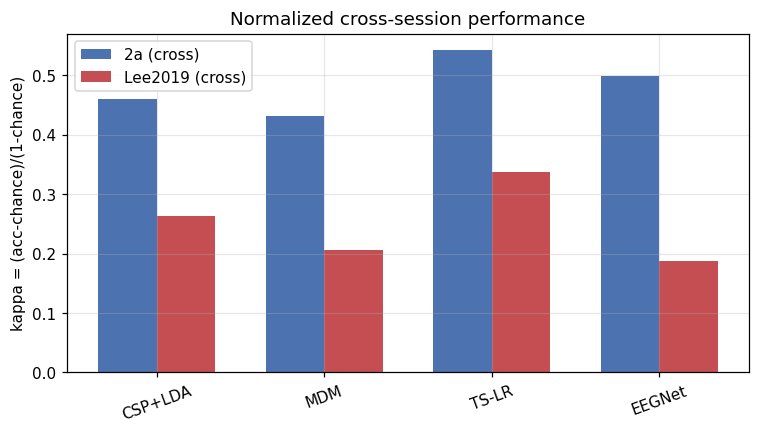

EEGNet kappa drop 2a->Lee2019: 0.499 -> 0.187 (-63%)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
a_k = {m: kappa(a_cross[a_cross.method == m].score.mean(), 0.25) for m in BASE}
l_k = {m: kappa(lee_cross[lee_cross.method == m].score.mean(), 0.50) for m in BASE}
x = np.arange(len(BASE)); w = 0.35
ax.bar(x - w/2, [a_k[m] for m in BASE], w, color="#4C72B0", label="2a (cross)")
ax.bar(x + w/2, [l_k[m] for m in BASE], w, color="#C44E52", label="Lee2019 (cross)")
ax.set_xticks(x); ax.set_xticklabels(BASE, rotation=20)
ax.set_ylabel("kappa = (acc-chance)/(1-chance)"); ax.set_title("Normalized cross-session performance")
ax.legend(); plt.show()
print("EEGNet kappa drop 2a->Lee2019:", f"{a_k['EEGNet']:.3f} -> {l_k['EEGNet']:.3f} "
      f"({(l_k['EEGNet']-a_k['EEGNet'])/a_k['EEGNet']*100:.0f}%)")

用 κ 归一化后,**EEGNet 的跨会话 κ 从 2a 到 Lee2019 下降 63%,是四种方法里降幅最大的(其余三种在 38% 到 52% 之间)**。EEGNet 的原始跨会话准确率在两个数据集上都接近 0.6,容易被当成没有变化;但随机水平从 25% 升到 50%,同样的准确率对应的 κ 差别很大,所以跨数据集比较只能用 κ,不能用原始准确率。

## 结论

1. **TS-LR(黎曼切空间)是最稳的方法**:within-session 与跨会话两个协议 × 两个数据集,全排第一(协议格子 1/1/1/1)。通道缩减时也基本最优,唯一例外是 2a 砍到 4 通道,EEGNet 点估计反超(0.563 vs 0.553,差 0.01、不到 1 个 SD,且该 K 下 Friedman p=0.14、方法间无显著差异,详见第 5 条)。
2. **RPA 的效应需要大样本才显著**:同样大小的效应,9 人时 p=0.055(不显著),54 人时 p=2.5e-5(显著)。
3. **n=9 样本不足**:跨会话退化在 9 人时检测不到(不显著),54 人才显著,直接说明了换大数据集的必要性。
4. **EEGNet 在真实小标定场景下不如经典方法**:它数据饥饿,Lee2019 每会话才 100 个 trial。
5. **复现核对(把 2a 的发现拿到 Lee2019 上验证)**:"通道越多、各方法差距越大" 复现成立;"2a 上 K=4 时 EEGNet 最强" 在 Lee2019 上反转(那里它最差);"EEGNet 退化最小" 实为 floor effect,非真鲁棒;"RPA 能补回跨会话损失" 复现成立,且在大样本上显著。

方法学:所有对比用 Friedman + Wilcoxon(Holm 校正),报告效应量 dz,并对随机水平用 κ 归一化。